# Lab 03
### 1.Convolution Neural Networks
### 2.Convolutions, Pooling, Activation functions, Dropout
### 3.Training, Predictions
### 4.VGG Architecture
### 4.Pretained CNN weights from Imagenet Data(VGG16)

In [1]:
import torch
import torchvision
print(torch.__version__)
print(torchvision.__version__)

2.12.1
0.27.1


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


# made this for mac gpu

In [37]:
import torch

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Device:", device)
else:
    print("MPS is not available on this Mac, keeping the existing device selection.")


Device: mps


# Data Cifar-10

In [3]:
import os
import tarfile
from torchvision.datasets.utils import download_url

In [4]:
# Dowload the dataset
dataset_url = "https://s3.amazonaws.com/fast-ai-imageclas/cifar10.tgz"
download_url(dataset_url, '.')

# Extract from archive
with tarfile.open('./cifar10.tgz', 'r:gz') as tar:
    tar.extractall(path='./data')

100%|██████████| 135M/135M [04:23<00:00, 513kB/s]  
/var/folders/rc/v7spqyl57gl721yw5q0dhn_00000gn/T/ipykernel_42465/1640521235.py:7: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path='./data')


In [38]:
data_dir = './data/cifar10'

print(os.listdir(data_dir))               # to check directories inside data_dir

classes = os.listdir(data_dir + "/train")   # to check directories inside train directory
print(classes)

airplane_files = os.listdir(data_dir + "/train/airplane")

print("No. of training examples for airplanes :", len(airplane_files))

['test', 'train']
['cat', 'dog', 'truck', 'bird', 'airplane', 'ship', 'frog', 'horse', 'deer', 'automobile']
No. of training examples for airplanes : 5000


In [39]:
from torchvision.datasets import ImageFolder
from torchvision.transforms import ToTensor

In [40]:
dataset = ImageFolder(data_dir + "/train", transform=ToTensor())

In [41]:
len(dataset)

image, label = dataset[9000]
print("image shape:",image.shape, "Label :", label)

image shape: torch.Size([3, 32, 32]) Label : 1


In [42]:
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

matplotlib.rcParams['figure.facecolor'] = '#ffffff'

In [43]:
def show_image(img, label):
  Label = dataset.classes[label]
  print("Label :", Label, "[" + str(label) + "]")

  image = img.permute(1,2,0)
  plt.imshow(image)

Label : automobile [1]


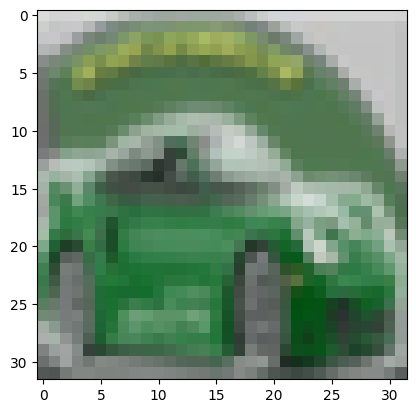

In [44]:
show_image(*dataset[9000])

In [45]:
from torch.utils.data import random_split

In [46]:
validation_size = 5000

training_size = len(dataset) - validation_size

train_dataset, valid_dataset = random_split(dataset, [training_size, validation_size])

print("Training size :", len(train_dataset))
print("Validation size :", len(valid_dataset))

Training size : 45000
Validation size : 5000


In [47]:
from torch.utils.data.dataloader import DataLoader

batch_size=64

In [48]:
train_dataloader = DataLoader(train_dataset, batch_size, shuffle=True, num_workers=2, pin_memory=True)

valid_dataloader = DataLoader(valid_dataset, batch_size, num_workers=2, pin_memory=True)

# Data Visualizing

In [49]:
from torchvision.utils import make_grid

In [50]:
def show_batch(data_loader):

  for images, labels in data_loader:

    fig, ax = plt.subplots(figsize=(12, 6))

    ax.set_xticks([]); ax.set_yticks([]);

    ax.imshow(make_grid(images, nrow=16).permute(1,2,0))     # as in tensor the order is C x W x H, so to show image we need order of W x H X C

    break


/opt/miniconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


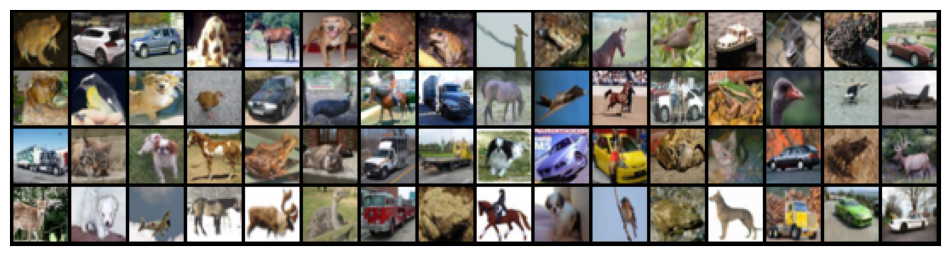

In [51]:
show_batch(train_dataloader)

# CNN Models

In [52]:
class CIFAR10Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=(3,3), stride=1, padding=1)
        self.act1 = nn.ReLU()

        self.conv2 = nn.Conv2d(32, 32, kernel_size=(3,3), stride=1, padding=1)
        self.act2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=(2, 2))

        self.flat = nn.Flatten()

        self.fc3 = nn.Linear(8192, 512)
        self.act3 = nn.ReLU()
        self.drop3 = nn.Dropout(0.5)

        self.fc4 = nn.Linear(512, 10)

    def forward(self, x):
        # input 3x32x32, output 32x32x32
        x = self.act1(self.conv1(x))
        # input 32x32x32, output 32x32x32
        x = self.act2(self.conv2(x))
        # input 32x32x32, output 32x16x16
        x = self.pool2(x)
        # input 32x16x16, output 8192
        x = self.flat(x)
        # input 8192, output 512
        x = self.act3(self.fc3(x))
        x = self.drop3(x)
        # input 512, output 10
        x = self.fc4(x)
        return x

model = CIFAR10Model().to(device)

In [53]:
#VGG16

In [54]:
import torch
import torch.nn as nn
class VGG16(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # Block 1
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        # Block 2
        self.block2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        # Block 3
        self.block3 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        # Block 4
        self.block4 = nn.Sequential(
            nn.Conv2d(256, 512, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        # Block 5
        self.block5 = nn.Sequential(
            nn.Conv2d(512, 512, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.flatten = nn.Flatten()
        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(4096, num_classes)
        )
    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.block5(x)

        x = self.flatten(x)
        x = self.classifier(x)
        return x
vgg166=VGG16()
print(vgg166)

VGG16(
  (block1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block4): 

# Training

In [55]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [56]:
epochs = 10

train_losses = []
train_accs = []
val_losses = []
val_accs = []

for epoch in range(epochs):

    # ===== TRAIN =====
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_dataloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        # print(labels.size(0))
        total += labels.size(0)#(1,100)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_dataloader)
    train_acc = 100 * correct / total

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # ===== VALIDATION =====
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in valid_dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss /= len(valid_dataloader)
    val_acc = 100 * correct / total

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {train_loss:.3f} "
          f"Train Acc: {train_acc:.2f}% "
          f"Val Loss:: { val_loss:.2f} "
          f"Val Acc: {val_acc:.2f}%")

Epoch [1/10] Train Loss: 1.527 Train Acc: 44.66% Val Loss:: 1.23 Val Acc: 56.52%
Epoch [2/10] Train Loss: 1.185 Train Acc: 57.52% Val Loss:: 1.08 Val Acc: 61.38%
Epoch [3/10] Train Loss: 1.025 Train Acc: 63.64% Val Loss:: 0.97 Val Acc: 65.56%
Epoch [4/10] Train Loss: 0.906 Train Acc: 68.06% Val Loss:: 0.96 Val Acc: 67.36%
Epoch [5/10] Train Loss: 0.808 Train Acc: 71.42% Val Loss:: 0.91 Val Acc: 67.60%
Epoch [6/10] Train Loss: 0.721 Train Acc: 74.34% Val Loss:: 0.89 Val Acc: 69.34%
Epoch [7/10] Train Loss: 0.642 Train Acc: 77.28% Val Loss:: 0.89 Val Acc: 70.16%
Epoch [8/10] Train Loss: 0.575 Train Acc: 79.41% Val Loss:: 0.93 Val Acc: 69.60%
Epoch [9/10] Train Loss: 0.512 Train Acc: 81.58% Val Loss:: 0.95 Val Acc: 69.34%
Epoch [10/10] Train Loss: 0.460 Train Acc: 83.56% Val Loss:: 0.99 Val Acc: 69.60%


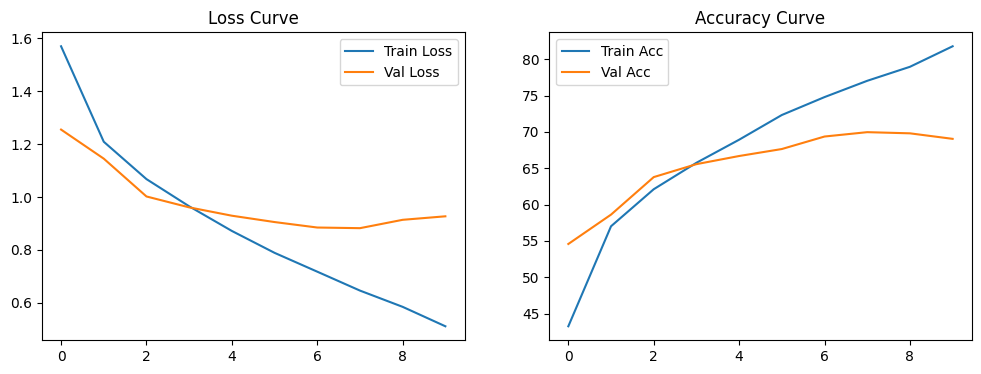

In [24]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss Curve")

plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.legend()
plt.title("Accuracy Curve")

plt.show()

In [25]:
torch.save(model.state_dict(), "cifar10model.pth")
print("Model saved!")

Model saved!


In [26]:
test_dataset = ImageFolder(data_dir+'/test', transform=ToTensor())
testloader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

<Figure size 800x800 with 0 Axes>

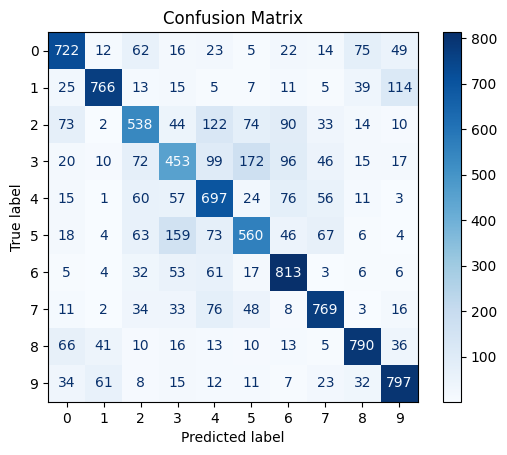

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

In [28]:
from sklearn.metrics import classification_report

# CIFAR-10 class names
class_names = classes

report = classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    digits=4
)

print("📊 Classification Report:\n")
print(report)

📊 Classification Report:

              precision    recall  f1-score   support

         cat     0.7300    0.7220    0.7260      1000
         dog     0.8483    0.7660    0.8050      1000
       truck     0.6031    0.5380    0.5687      1000
        bird     0.5261    0.4530    0.4868      1000
    airplane     0.5902    0.6970    0.6392      1000
        ship     0.6034    0.5600    0.5809      1000
        frog     0.6878    0.8130    0.7452      1000
       horse     0.7532    0.7690    0.7610      1000
        deer     0.7972    0.7900    0.7936      1000
  automobile     0.7576    0.7970    0.7768      1000

    accuracy                         0.6905     10000
   macro avg     0.6897    0.6905    0.6883     10000
weighted avg     0.6897    0.6905    0.6883     10000



In [29]:
# classes = trainset.classes

mis_images = []
mis_preds = []
mis_labels = []

model.eval()
with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        for i in range(len(images)):
            if preds[i] != labels[i]:
                mis_images.append(images[i].cpu())
                mis_preds.append(preds[i].cpu())
                mis_labels.append(labels[i].cpu())

            if len(mis_images) >= 16:
                break
        if len(mis_images) >= 16:
            break

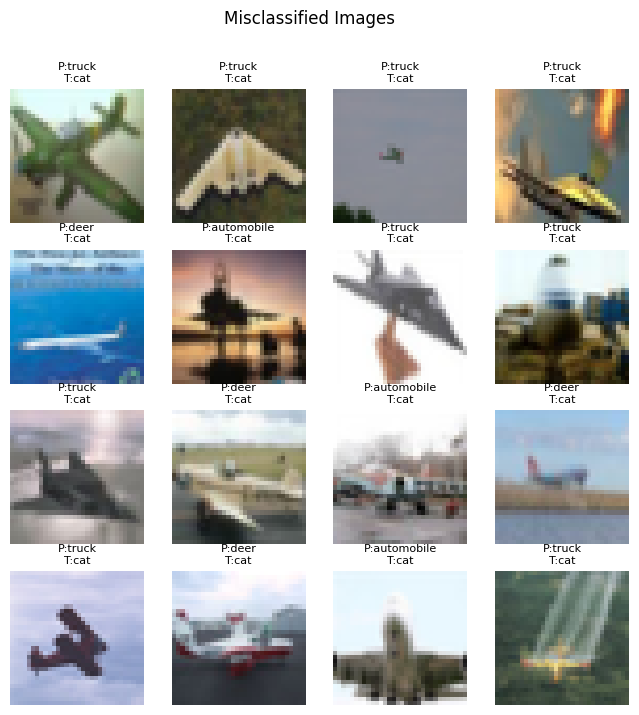

In [30]:
fig, ax = plt.subplots(4,4, figsize=(8,8))

for i in range(16):
    r, c = i//4, i%4
    img = mis_images[i].permute(1,2,0)

    ax[r][c].imshow(img)
    ax[r][c].set_title(
        f"P:{classes[mis_preds[i]]}\nT:{classes[mis_labels[i]]}",
        fontsize=8
    )
    ax[r][c].axis("off")

plt.suptitle("Misclassified Images")
plt.show()

In [31]:
model.load_state_dict(torch.load("cifar10model.pth"))

<All keys matched successfully>

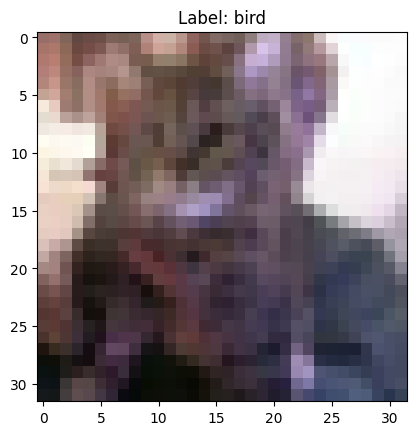

In [32]:
img, label = train_dataset[7]
#img = img * 0.5 + 0.5
plt.imshow(np.transpose(img.numpy(), (1,2,0)))
plt.title(f"Label: {classes[label]}")
plt.show()

# 1. Identify Problems In Model building and Training
# 2. Train the model with best approach you can understand


# Pre-trained CNN Models(ImageNet Data)
### VGG16

In [33]:
from google.colab import files

uploaded = files.upload()

ModuleNotFoundError: No module named 'google.colab'

In [34]:
import torch
import torch.nn.functional as F
from torchvision import models, transforms
from PIL import Image
import json
import urllib.request

# 1 Load pretrained VGG16
model = models.vgg16(pretrained=True)
model.eval()

# 2 Preprocessing (ImageNet standard)
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# 3 Load image
img_path = "images/aero.jfif"
img = Image.open(img_path).convert("RGB")
input_tensor = preprocess(img)
input_batch = input_tensor.unsqueeze(0)

# 4 Inference
with torch.no_grad():
    outputs = model(input_batch)
    probabilities = F.softmax(outputs, dim=1)


# 5 Load labels
url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
class_idx = urllib.request.urlopen(url).read().decode("utf-8").splitlines()
print(class_idx)

# 6 Top 3 Predictions
top3_prob, top3_catid = torch.topk(probabilities, 3)

print("Predictions:")
for i in range(top3_prob.size(1)):
    print(f"{class_idx[top3_catid[0][i]]} : {t0][iop3_prob[].item():.4f}")

SyntaxError: f-string: unmatched ']' (3697774973.py, line 45)

In [ ]:
class_idx[0]

In [ ]:
print(model)

In [ ]:
from torchinfo import summary
summary(model)